# Exercise 5.1

Write a second-order solver for the linear advection equation. To mimic a real hydrodynamics code, your code should have routines for initializing the state, filling boundary conditions, computing the timestep, constructing the interface states, solving thr Riemann problem, and doing the update. The problem flow should look like:

- set initial conditions
- main evolution loop -- loop until final time reached
    - fill boundary conditions
    - get timestep
    - compute interface states
    - solve Riemann problem at all interfaces
    - do conservative update

# Exercise 5.2

To remove the oscillations in practice, we limit the slopes to ensure that no new minima or maxima are introduced during the advection process. There are many choices for limited slopes. A popular one is the minmod limiter. Here, we construct the slopes in the interface states as:

$$
\frac{\partial a}{\partial x} |_i = \texttt{minmod}\left( \frac{a_i - a_{i-1}}{\Delta x}, \frac{a_{i+1} - a_i}{\Delta x} \right)
$$

with 

$$
\texttt{minmod}(a,b) = 
\begin{cases}
a, & \quad |a| < |b| \quad \text{and } a \cdot b > 0, \\
b, & \quad |b| < |a| \quad \text{and } a \cdot b > 0, \\
0, & \quad otherwise
\end{cases}
$$


In [7]:
import numpy as np
import matplotlib.pyplot as plt


In [8]:

#number of ghost cells for periodic BCs
nghost = 2


In [9]:
# Initial conditions
def top_hat_IC(x):
    if 0 <= x < 1/3:
        return 0.0
    elif 1/3 <= x < 2/3:
        return 1.0
    else:
        return 0.0
    
def Gaussian_IC(x, mu=0.5, sigma=0.1):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

In [10]:
# Periodic BCs: fill ghost cells by copying from the opposite end of the array
def fill_ghost_periodic_bc(a):
    nx = len(a) - 2*nghost
    a[:nghost] = a[nx:nx+nghost] # left ghost cells
    a[nx+nghost:] = a[nghost:2*nghost] # right ghost cells
    return a


In [11]:
# Compute interface states using unlimited linear reconstruction
def compute_interface_states_unlimited(a, dx, C):
    n = len(a)
    a_L = np.zeros_like(a)
    a_R = np.zeros_like(a)
    for i in range(nghost - 1, n - nghost):
        a_L[i] = a[i] + (0.5 * dx) *(1 - C) * (a[i+1] - a[i-1])/(2*dx)
        a_R[i] = a[i] - (0.5 * dx) *(1 + C) * (a[i+1] - a[i-1])/(2*dx)
    return a_L, a_R

In [12]:
# Compute interface states using minmod slope limiter

def minmod(a, b):
    if np.abs(a) < np.abs(b) and (a * b > 0):
        return a
    elif np.abs(b) < np.abs(a) and (a * b > 0):
        return b
    else:
        return 0.0

def compute_interface_states_minmod(a, dx, C):
    n = len(a)
    a_L = np.zeros_like(a)
    a_R = np.zeros_like(a)
    for i in range(nghost-1, n - nghost):
        backward = (a[i] - a[i-1]) / dx   # (a[i] - a[i-1]) / dx
        forward  = (a[i+1] - a[i]) / dx  # (a[i+1] - a[i]) / dx
        slope = minmod(backward, forward)
        a_L[i] = a[i] + 0.5 * dx * (1 - C) * slope
        a_R[i] = a[i] - 0.5 * dx * (1 + C) * slope
    return a_L, a_R



In [13]:
# Riemann solver for advection equation: simply return the upwind state based on the sign of u
def Riemann(a_L, a_R, u):
    if u > 0:
        return a_L
    else:
        return a_R


In [14]:
# Evolve the solution in time using the specified reconstruction method (unlimited or minmod)

def evolve(a_ghosted, nx, u, C, t_final, unlimited, minmod):
    dx = 1.0 / nx
    dt = C * dx / u

    a = np.zeros(nx + 2*nghost)
    a[nghost:nghost+nx] = a_ghosted

    t = 0.0
    while t < t_final:
        fill_ghost_periodic_bc(a)
        dt = min(dt, t_final - t) # adjust final time step to hit t_final exactly

        if unlimited:
            a_L, a_R = compute_interface_states_unlimited(a, dx, C)
        if minmod:
            a_L, a_R = compute_interface_states_minmod(a, dx, C)

        a_flux = Riemann(a_L, a_R, u)

        for i in range(nghost, nghost+nx):
            a[i] = a[i] - (dt/dx) * (a_flux[i] - a_flux[i-1])
        t += dt

    return a[nghost:nghost+nx]


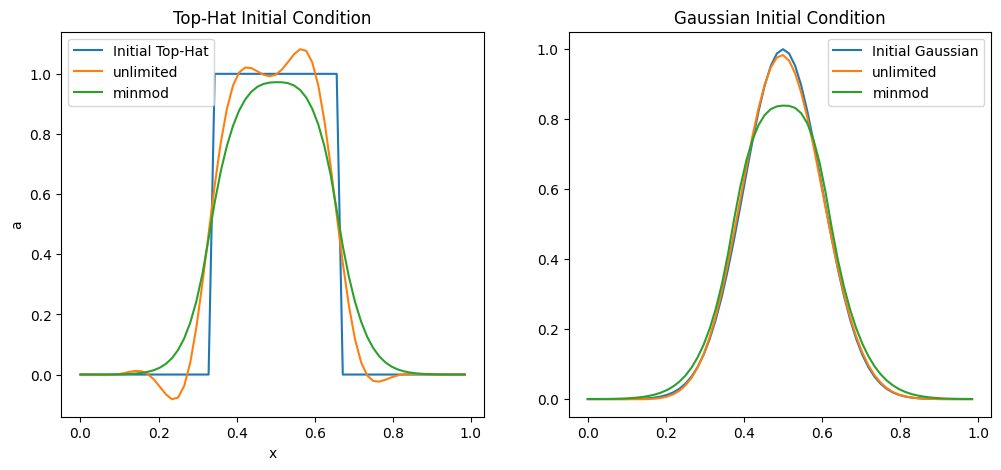

In [15]:
# Set parameters and run the simulation for both initial conditions and reconstruction methods

nx = 64
u = 1.0
C = 0.7
t_final = 5.0

X = np.linspace(0, 1, nx, endpoint=False)

a0_top = np.array([top_hat_IC(x) for x in X])
a0_gaussian = np.array([Gaussian_IC(x) for x in X])

a_top_minmod = evolve(a0_top.copy(), nx, u, C, t_final, unlimited=False, minmod=True)
a_gaussian_minmod = evolve(a0_gaussian.copy(), nx, u, C, t_final, unlimited=False, minmod=True)

a_top_unlimited = evolve(a0_top.copy(), nx, u, C, t_final, unlimited=True, minmod=False)
a_gaussian_unlimited = evolve(a0_gaussian.copy(), nx, u, C, t_final, unlimited=True, minmod=False)


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(X, a0_top, label='Initial Top-Hat')
plt.plot(X, a_top_unlimited, label='unlimited')
plt.plot(X, a_top_minmod, label='minmod')
plt.title('Top-Hat Initial Condition')
plt.xlabel('x')
plt.ylabel('a')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(X, a0_gaussian, label='Initial Gaussian')
plt.plot(X, a_gaussian_unlimited, label='unlimited')
plt.plot(X, a_gaussian_minmod, label='minmod')
plt.legend()
plt.title('Gaussian Initial Condition')
plt.show()